# Asthma Prescribing in NHS Primary Care
### A Python analysis of utilisation, cost and geographic variation in selected inhaler brands 2025/26

This project uses NHS primary care prescribing data to explore differences in prescribing volume, actual cost, geographic variation and monthly trends across six selected asthma inhaler brands in England.

## Research Question

**How do prescribing volume, cost, and geographic variation differ between selected commonly prescribed asthma inhaler brands in NHS primary care during the 2025/26 financial year?**

### Subquestions

1. Which inhaler brands had the highest prescribing volume and total actual cost?
2. How does cost per prescription item differ between the selected inhaler brands?
3. How much does prescribing vary between NHS areas for each inhaler brand?
4. How did prescribing volume and cost change over time from April 2025 to March 2026?

## Data Source & Methodology

Prescribing data were obtained from OpenPrescribing, a platform developed by the Bennett Institute for Applied Data Science at the University of Oxford using NHS primary care prescribing data.

Brand-level prescribing data were collected for six selected inhaler brands: Ventolin, Clenil Modulite, Pulmicort, Symbicort, Fostair and Seretide. These represent a range of therapeutic classes, including short acting beta₂ agonist (SABA), inhaled corticosteroid (ICS), and combined ICS/long acting beta₂ agonist (ICS/LABA) treatments.

The analysis covers the 2025/26 financial year, from April 2025 to March 2026. For each brand, the analysis used prescription item counts and actual NHS cost across NHS areas in England.

Prescription items represent the number of times a selected product appeared as a prescribed item and do not represent the number of individual inhalers supplied or patients treated. Actual Cost represents the estimated cost to the NHS in pounds sterling.



## Data Preparation/Cleaning

The six datasets were imported, cleaned and combined using Python and pandas. Dates were converted to datetime format, the data were restricted to the study period, and duplicate and missing values were checked. NHS Medway (09W) was excluded because it recorded zero prescription items and zero actual cost across all six selected brands throughout the study period.

The final analysis examined prescribing volume, total actual cost, average cost per prescription item, geographic variation across NHS areas, and monthly prescribing and expenditure trends.

In [9]:
import pandas as pd

ventolin = pd.read_csv("../data/ventolin.csv")
clenil = pd.read_csv("../data/clenil_modulite.csv")
pulmicort = pd.read_csv("../data/pulmicort.csv")
symbicort = pd.read_csv("../data/symbicort.csv")
fostair = pd.read_csv("../data/fostair.csv")
seretide = pd.read_csv("../data/seretide.csv")

In [10]:
datasets = {
    "Ventolin": ventolin,
    "Clenil": clenil,
    "Pulmicort": pulmicort,
    "Symbicort": symbicort,
    "Fostair": fostair,
    "Seretide": seretide
}

In [11]:
for name, df in datasets.items():
    print(name,list(df.columns))

Ventolin ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']
Clenil ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']
Pulmicort ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']
Symbicort ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']
Fostair ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']
Seretide ['date', 'id', 'name', 'y_items', 'y_actual_cost', 'x_items', 'x_actual_cost']


In [13]:
columns_to_keep = [
    'date',
    'id',
    'name',
    'y_items',
    'y_actual_cost'
]

for name, df in datasets.items():
    datasets[name]= df[columns_to_keep]
print(name, list(df.columns))

Seretide ['date', 'id', 'name', 'y_items', 'y_actual_cost']


In [14]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.info())


Ventolin
<class 'pandas.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           6480 non-null   str    
 1   id             6480 non-null   str    
 2   name           6480 non-null   str    
 3   y_items        6480 non-null   int64  
 4   y_actual_cost  6480 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 253.3 KB
None

Clenil
<class 'pandas.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           6480 non-null   str    
 1   id             6480 non-null   str    
 2   name           6480 non-null   str    
 3   y_items        6480 non-null   int64  
 4   y_actual_cost  6480 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 253.3 KB
None

Pulmicort
<class 'pandas.DataFrame'>
RangeInd

In [15]:
for name, df in datasets.items():
    df['date'] = pd.to_datetime(df.date)

In [19]:
for name, df in datasets.items():
    print(df.dtypes)

date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_actual_cost           float64
dtype: object
date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_actual_cost           float64
dtype: object
date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_actual_cost           float64
dtype: object
date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_actual_cost           float64
dtype: object
date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_actual_cost           float64
dtype: object
date             datetime64[us]
id                          str
name                        str
y_items                   int64
y_

In [20]:
for name, df in datasets.items():
    print(name, df.duplicated().sum())

Ventolin 0
Clenil 0
Pulmicort 0
Symbicort 0
Fostair 0
Seretide 0


In [31]:
for name, df in datasets.items():
    df.rename(columns={
        "y_items": "items",
        "y_actual_cost": "actual_cost"
    }, inplace=True)

for name, df in datasets.items():
    print(name)
    display(df.head(
    ))

Ventolin


,date,id,name,items,actual_cost
0,2021-07-01,09W,NHS MEDWAY,0,0.00
1,2021-07-01,D4U1Y,NHS FRIMLEY,51,77.84
2,2021-07-01,03Q,NHS VALE OF YORK,280,713.57
3,2021-07-01,00N,NHS SOUTH TYNESIDE,392,828.34
4,2021-07-01,00Q,NHS BLACKBURN WITH DARWEN,413,862.17


Clenil


,date,id,name,items,actual_cost
0,2021-07-01,09W,NHS MEDWAY,0,0.00
1,2021-07-01,D4U1Y,NHS FRIMLEY,32,223.20
2,2021-07-01,99G,NHS SOUTHEND,593,4986.91
3,2021-07-01,07G,NHS THURROCK,619,4594.45
4,2021-07-01,99F,NHS CASTLE POINT AND ROCHFORD,624,5010.27


Pulmicort


...

,date,id,name,items,actual_cost
0,2021-07-01,09W,NHS MEDWAY,0,0.00
1,2021-07-01,D4U1Y,NHS FRIMLEY,3,78.36
2,2021-07-01,00Q,NHS BLACKBURN WITH DARWEN,164,4910.75
3,2021-07-01,03H,NHS NORTH EAST LINCOLNSHIRE,168,5015.15
4,2021-07-01,02G,NHS WEST LANCASHIRE,255,8254.00


Fostair


,date,id,name,items,actual_cost
0,2021-07-01,09W,NHS MEDWAY,0,0.00
1,2021-07-01,D4U1Y,NHS FRIMLEY,5,136.76
2,2021-07-01,99C,NHS NORTH TYNESIDE,679,24560.78
3,2021-07-01,99G,NHS SOUTHEND,1101,36705.49
4,2021-07-01,01V,NHS SOUTHPORT AND FORMBY,1156,35229.81


Seretide


,date,id,name,items,actual_cost
0,2021-07-01,09W,NHS MEDWAY,0,0.00
1,2021-07-01,D4U1Y,NHS FRIMLEY,4,101.65
2,2021-07-01,00R,NHS BLACKPOOL,239,6576.80
3,2021-07-01,05D,NHS EAST STAFFORDSHIRE,243,6880.56
4,2021-07-01,02Q,NHS BASSETLAW,250,6063.49


In [34]:
for name, df in datasets.items():
    datasets[name] = df[
        (df["date"] >= "2025-04-01") &
        (df["date"] <= "2026-03-01")
    ]
for name, df in datasets.items():
    datasets[name] = df.reset_index(drop=True)

for name, df in datasets.items():
        print(name)
        display(df.head())

Ventolin


,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.00
1,2025-04-01,D4U1Y,NHS FRIMLEY,42,66.36
2,2025-04-01,03Q,NHS VALE OF YORK,282,611.99
3,2025-04-01,02Q,NHS BASSETLAW,375,749.10
4,2025-04-01,00Q,NHS BLACKBURN WITH DARWEN,391,793.14


Clenil


,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.00
1,2025-04-01,D4U1Y,NHS FRIMLEY,68,525.65
2,2025-04-01,07G,NHS THURROCK,296,2233.75
3,2025-04-01,12F,NHS WIRRAL,321,2601.70
4,2025-04-01,99F,NHS CASTLE POINT AND ROCHFORD,342,2742.87


Pulmicort


...

,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.00
1,2025-04-01,D4U1Y,NHS FRIMLEY,12,319.35
2,2025-04-01,02G,NHS WEST LANCASHIRE,269,9047.56
3,2025-04-01,00Q,NHS BLACKBURN WITH DARWEN,294,8968.11
4,2025-04-01,03H,NHS NORTH EAST LINCOLNSHIRE,349,10512.40


Fostair


,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.00
1,2025-04-01,D4U1Y,NHS FRIMLEY,14,410.65
2,2025-04-01,01G,NHS SALFORD,340,11145.75
3,2025-04-01,10R,NHS PORTSMOUTH,465,23285.84
4,2025-04-01,01T,NHS SOUTH SEFTON,528,17041.46


Seretide


,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.00
1,2025-04-01,D4U1Y,NHS FRIMLEY,6,120.96
2,2025-04-01,05D,NHS EAST STAFFORDSHIRE,159,4643.25
3,2025-04-01,07G,NHS THURROCK,186,5125.81
4,2025-04-01,00R,NHS BLACKPOOL,190,5077.85


In [37]:
datasets["Ventolin"][
    datasets["Ventolin"]["name"] == "NHS MEDWAY"
]

,date,id,name,items,actual_cost
0,2025-04-01,09W,NHS MEDWAY,0,0.0
108,2025-05-01,09W,NHS MEDWAY,0,0.0
216,2025-06-01,09W,NHS MEDWAY,0,0.0
324,2025-07-01,09W,NHS MEDWAY,0,0.0
432,2025-08-01,09W,NHS MEDWAY,0,0.0
540,2025-09-01,09W,NHS MEDWAY,0,0.0
648,2025-10-01,09W,NHS MEDWAY,0,0.0
756,2025-11-01,09W,NHS MEDWAY,0,0.0
864,2025-12-01,09W,NHS MEDWAY,0,0.0
972,2026-01-01,09W,NHS MEDWAY,0,0.0


In [39]:
asthma_data = pd.concat(datasets.values(), ignore_index=True)
print(asthma_data.head())

        date     id                       name  items  actual_cost
0 2025-04-01    09W                 NHS MEDWAY      0         0.00
1 2025-04-01  D4U1Y                NHS FRIMLEY     42        66.36
2 2025-04-01    03Q           NHS VALE OF YORK    282       611.99
3 2025-04-01    02Q              NHS BASSETLAW    375       749.10
4 2025-04-01    00Q  NHS BLACKBURN WITH DARWEN    391       793.14


In [40]:
chemicals = {
    "Ventolin": "Salbutamol",
    "Clenil": "Beclometasone",
    "Pulmicort": "Budesonide",
    "Symbicort": "Budesonide/Formoterol",
    "Fostair": "Beclometasone/Formoterol",
    "Seretide": "Fluticasone/Salmeterol"
}

for name, df in datasets.items():
    df["chemical"] = chemicals[name]

In [42]:
classes = {
    "Ventolin": "SABA",
    "Clenil": "ICS",
    "Pulmicort": "ICS",
    "Symbicort": "ICS/LABA",
    "Fostair": "ICS/LABA",
    "Seretide": "ICS/LABA"
}

for name, df in datasets.items():
    df["class"] = classes[name]

In [48]:
for name, df in datasets.items():
    df["inhaler"] = name

column_order = [
    "inhaler",
    "chemical",
    "class",
    "date",
    "id",
    "name",
    "items",
    "actual_cost"
]

for name, df in datasets.items():
    datasets[name] = df[column_order]

In [57]:
for name, df in datasets.items():
    df.columns = [
        "Inhaler",
        "Chemical",
        "Class",
        "Date",
        "ID",
        "NHS Area",
        "Items",
        "Actual Cost"
    ]


datasets["Ventolin"].head()
asthma_data = pd.concat(datasets.values(), ignore_index=True)


In [60]:
print(asthma_data.columns)
asthma_data["Inhaler"].value_counts()


Index(['Inhaler', 'Chemical', 'Class', 'Date', 'ID', 'NHS Area', 'Items',
       'Actual Cost'],
      dtype='str')


Inhaler
Ventolin     1296
Clenil       1296
Pulmicort    1296
Symbicort    1296
Fostair      1296
Seretide     1296
Name: count, dtype: int64

In [64]:
df = asthma_data
df.shape

(7776, 8)

In [65]:
df["Date"].min(), df["Date"].max()

(Timestamp('2025-04-01 00:00:00'), Timestamp('2026-03-01 00:00:00'))

In [66]:
df.groupby(["ID", "NHS Area"])[["Items", "Actual Cost"]].sum()


,,Items,Actual Cost
ID,NHS Area,,
00L,NHS NORTHUMBERLAND,95699,2215131.88
00N,NHS SOUTH TYNESIDE,59429,1373970.24
00P,NHS SUNDERLAND,102796,2216450.49
00Q,NHS BLACKBURN WITH DARWEN,54855,1334651.78
00R,NHS BLACKPOOL,52835,1149824.55
...,...,...,...
M1J4Y,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES",231924,5238180.63
M2L0M,"NHS SHROPSHIRE, TELFORD AND WREKIN",112158,2713866.54
U2G6B,NHS THAMES VALLEY ICB - U2G6B,80949,2219058.47


In [67]:
area_totals = df.groupby(["ID", "NHS Area"])[["Items", "Actual Cost"]].sum()

area_totals[
    (area_totals["Items"] == 0) &
    (area_totals["Actual Cost"] == 0)
]

,,Items,Actual Cost
ID,NHS Area,,
09W,NHS MEDWAY,0,0.0


In [69]:
df = df[df["ID"] != "09W"].reset_index(drop=True)
df["NHS Area"].nunique()

107

In [71]:
df = df.rename(columns={
    "Items": "Prescription Items",
    "Actual Cost": "Actual Cost (£)"
})

## Q1 - Which inhaler brands had the highest prescribing volume and total actual cost?


In [90]:
volume_summary = inhaler_summary[["Prescription Items", "Prescription Items (millions)"]].sort_values(
    by="Prescription Items",
    ascending=False
)



volume_summary



,Prescription Items,Prescription Items (millions)
Inhaler,,
Fostair,4192805,4.192805
Symbicort,2906514,2.906514
Ventolin,2888927,2.888927
Clenil,2595503,2.595503
Seretide,1036326,1.036326
Pulmicort,120046,0.120046


In [92]:
cost_summary = inhaler_summary[["Actual Cost (£)", "Actual Cost (£m)"]].sort_values(
    by="Actual Cost (£)",
    ascending=False
)

volume_summary["Prescription Items (millions)"] = volume_summary["Prescription Items (millions)"].round(2)

cost_summary

,Actual Cost (£),Actual Cost (£m)
Inhaler,,
Fostair,1.503529e+08,150.352935
Symbicort,1.023489e+08,102.348872
Seretide,3.085462e+07,30.854615
Clenil,2.238833e+07,22.388325
Ventolin,6.106357e+06,6.106357
Pulmicort,2.419067e+06,2.419067



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


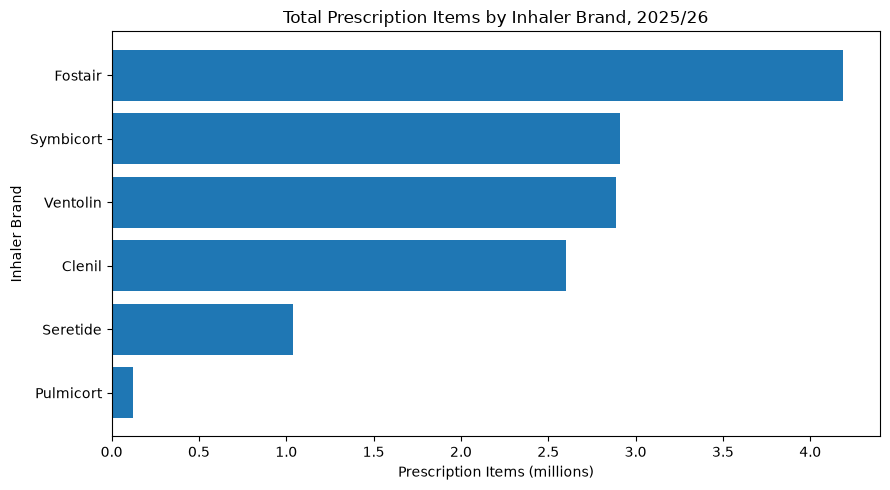

In [97]:
%pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(
    volume_summary.index,
    volume_summary["Prescription Items (millions)"]
)

plt.xlabel("Prescription Items (millions)")
plt.ylabel("Inhaler Brand")
plt.title("Total Prescription Items by Inhaler Brand, 2025/26")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/figures/prescription_items_by_inhaler.png", dpi=300, bbox_inches="tight")
plt.show()

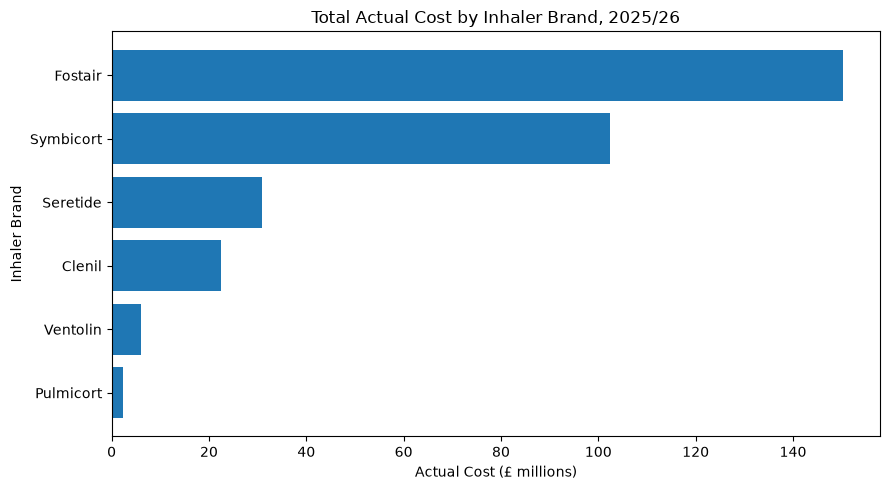

In [98]:
plt.figure(figsize=(9, 5))

plt.barh(
    cost_summary.index,
    cost_summary["Actual Cost (£m)"]
)

plt.xlabel("Actual Cost (£ millions)")
plt.ylabel("Inhaler Brand")
plt.title("Total Actual Cost by Inhaler Brand, 2025/26")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../outputs/figures/actual_cost_by_inhaler.png", dpi=300, bbox_inches="tight")

plt.show()

Across the 107 NHS areas included in the analysis, Fostair had the highest prescribing volume of the six selected inhaler brands during April 2025-March 2026, with approximately 4.19 million prescription items. This was followed by Symbicort (2.91 million), Ventolin (2.89 million) and Clenil (2.60 million). Seretide (1.04 million) was prescribed substantially less frequently, while Pulmicort had the lowest volume at approximately 0.12 million items.

There were also substantial differences in total actual cost. Fostair accounted for the greatest expenditure at approximately £150.35 million, followed by Symbicort at £102.35 million and Seretide at £30.85 million. Clenil accounted for approximately £22.39 million, while Ventolin and Pulmicort had considerably lower total costs of approximately £6.11 million and £2.42 million, respectively.

Importantly, the ranking by expenditure did not exactly match the ranking by prescribing volume. Ventolin was the third most frequently prescribed brand but only fifth by total actual cost, whereas Seretide ranked fifth by prescription volume but third by cost. This suggests substantial differences in expenditure per prescription item between brands, owing to further analysis as explored in the next analysis question.

The selected brands also represent different therapeutic classes and roles, including SABA reliever therapy, ICS preventer therapy and ICS/LABA combination therapy. Consequently, differences in prescribing volume should not be interpreted as direct comparisons of interchangeable treatments.

## Q2 - How does cost per prescription item differ between the selected inhaler brands?



In [102]:
cost_per_prescription = inhaler_summary["Actual Cost (£)"] / inhaler_summary["Prescription Items"]
inhaler_summary["Cost per Prescription Item (£)"] = cost_per_prescription
inhaler_summary

,Prescription Items,Actual Cost (£),Actual Cost (£m),Prescription Items (millions),Cost per Prescription Item (£)
Inhaler,,,,,
Clenil,2595503,2.238833e+07,22.388325,2.595503,8.625814
Fostair,4192805,1.503529e+08,150.352935,4.192805,35.859749
Pulmicort,120046,2.419067e+06,2.419067,0.120046,20.151167
Seretide,1036326,3.085462e+07,30.854615,1.036326,29.773079
Symbicort,2906514,1.023489e+08,102.348872,2.906514,35.213618
Ventolin,2888927,6.106357e+06,6.106357,2.888927,2.113711


In [106]:
cost_per_item_summary = inhaler_summary[["Cost per Prescription Item (£)"]].sort_values(
    by="Cost per Prescription Item (£)",
    ascending=False
)
cost_per_item_summary.round(2)


,Cost per Prescription Item (£)
Inhaler,
Fostair,35.86
Symbicort,35.21
Seretide,29.77
Pulmicort,20.15
Clenil,8.63
Ventolin,2.11


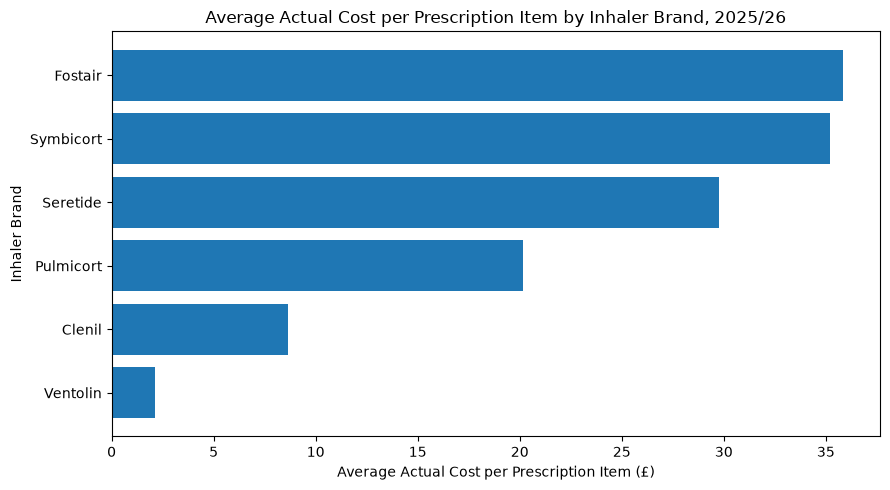

In [104]:
plt.figure(figsize=(9, 5))

plt.barh(
    cost_per_item_summary.index,
    cost_per_item_summary["Cost per Prescription Item (£)"]
)

plt.xlabel("Average Actual Cost per Prescription Item (£)")
plt.ylabel("Inhaler Brand")
plt.title("Average Actual Cost per Prescription Item by Inhaler Brand, 2025/26")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/cost_per_prescription_item_by_inhaler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
cost_per_item_summary.round(2)


,Cost per Prescription Item (£)
Inhaler,
Fostair,35.86
Symbicort,35.21
Seretide,29.77
Pulmicort,20.15
Clenil,8.63
Ventolin,2.11


Average actual cost per prescription item varied markedly between the six selected inhaler brands. Fostair had the highest average cost per item at £35.86, closely followed by Symbicort at £35.21. Seretide was also relatively high at £29.77 per item, while Pulmicort averaged £20.15. In contrast, Clenil and Ventolin had much lower average costs per item at £8.63 and £2.11, respectively.

These differences help explain why the ranking by total expenditure did not exactly match the ranking by prescribing volume. For example, Seretide had substantially fewer prescription items than Ventolin but still generated a higher total actual cost, because its average cost per item was much greater.

The high total expenditure associated with Fostair and Symbicort therefore appears to reflect a combination of high prescribing volume and relatively high average cost per prescription item.

These figures should not be interpreted as direct price comparisons, however, because the selected brands contain different medicines, formulations and therapeutic classes and thus varibles are not controlled enough for completley accurate comparison

## Q3. How much does prescribing vary between NHS areas for each inhaler brand?

In [111]:
area_summary = df.groupby(
    ["Inhaler", "NHS Area"]
)[["Prescription Items", "Actual Cost (£)"]].sum()
area_summary

Prescription Items  \
Inhaler  NHS Area                                                                 
Clenil   NHS BARNSLEY                                                      6358   
         NHS BASILDON AND BRENTWOOD                                        5422   
         NHS BASSETLAW                                                     7110   
         NHS BATH AND NORTH EAST SOMERSET, SWINDON AND W...               37396   
         NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES                        47394   
...                                                                         ...   
Ventolin NHS WEST LEICESTERSHIRE                                          21762   
         NHS WEST SUFFOLK                                                  8090   
         NHS WEST SUSSEX                                                  37753   
         NHS WIGAN BOROUGH                                                22124   
         NHS WIRRAL                                                       28331   

                                                             Actual Cost (£)  
Inhaler  NHS Area                                                             
Clenil   NHS BARNSLEY                                               49827.11  
         NHS BASILDON AND BRENTWOOD                                 43733.05  
         NHS BASSETLAW                                              53089.38  
         NHS BATH AND NORTH EAST SOMERSET, SWINDON AND W...        294694.13  
         NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES                 371780.62  
...                                                                      ...  
Ventolin NHS WEST LEICESTERSHIRE                                    41186.65  
         NHS WEST SUFFOLK                                           14552.68  
         NHS WEST SUSSEX                                            90688.49  
         NHS WIGAN BOROUGH                                          48083.01  
         NHS WIRRAL                                                 57830.56  

[642 rows x 2 columns]

In [113]:
area_summary = area_summary.reset_index()
area_summary.head()

,index,Inhaler,NHS Area,Prescription Items,Actual Cost (£)
0,0,Clenil,NHS BARNSLEY,6358,49827.11
1,1,Clenil,NHS BASILDON AND BRENTWOOD,5422,43733.05
2,2,Clenil,NHS BASSETLAW,7110,53089.38
3,3,Clenil,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",37396,294694.13
4,4,Clenil,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES",47394,371780.62


In [115]:
geographic_variation = area_summary.groupby("Inhaler")["Prescription Items"].agg(
    ["min", "median", "max", "mean", "std"]
)

geographic_variation

,min,median,max,mean,std
Inhaler,,,,,
Clenil,616,17044.0,108324,24257.037383,21531.029767
Fostair,313,30857.0,150243,39185.093458,29452.239318
Pulmicort,2,709.0,5389,1121.925234,1031.696036
Seretide,33,6791.0,39772,9685.289720,7639.793438
Symbicort,231,16922.0,132981,27163.682243,24658.878046
Ventolin,326,19847.0,142221,26999.317757,24566.950041


In [120]:
geographic_variation["Coefficient of Variation"] = (
    geographic_variation["std"] / geographic_variation["mean"]
)

geographic_variation.sort_values(
    by="Coefficient of Variation",
    ascending=False
).round(2)



,min,median,max,mean,std,Coefficient of Variation
Inhaler,,,,,,
Pulmicort,2,709.0,5389,1121.93,1031.70,0.92
Ventolin,326,19847.0,142221,26999.32,24566.95,0.91
Symbicort,231,16922.0,132981,27163.68,24658.88,0.91
Clenil,616,17044.0,108324,24257.04,21531.03,0.89
Seretide,33,6791.0,39772,9685.29,7639.79,0.79
Fostair,313,30857.0,150243,39185.09,29452.24,0.75


<Figure size 1000x600 with 0 Axes>

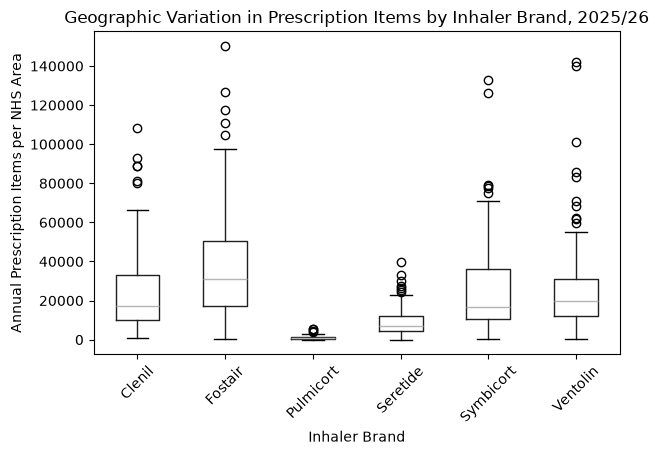

In [123]:
plt.figure(figsize=(10, 6))

area_summary.boxplot(
    column="Prescription Items",
    by="Inhaler",
    grid=False
)

plt.xlabel("Inhaler Brand")
plt.ylabel("Annual Prescription Items per NHS Area")
plt.title("Geographic Variation in Prescription Items by Inhaler Brand, 2025/26")
plt.suptitle("")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/geographic_variation_by_inhaler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key findings — geographic variation

Prescribing volume varied substantially between NHS areas for all six selected inhaler brands. Relative geographic variation was greatest for Pulmicort, which had a coefficient of variation of approximately 0.92. Ventolin and Symbicort showed similarly high relative variation, with coefficients of approximately 0.91 each, followed by Clenil at 0.89.

Seretide showed somewhat lower relative variation, with a coefficient of variation of approximately 0.79, while Fostair had the lowest relative variation at approximately 0.75. Despite this, prescribing was still widely distributed across areas for every brand.

The absolute spread in prescribing was also large. For example, annual Fostair prescribing ranged from approximately 313 to 150,243 prescription items per NHS area, while Ventolin ranged from approximately 326 to 142,221 items. Pulmicort had much lower prescribing overall, ranging from only 2 to 5,389 items, but its high coefficient of variation shows that its prescribing was particularly uneven relative to its average level.

These results suggest that prescribing patterns differed considerably between NHS areas, although the extent of variation was not identical across inhaler brands.

Importantly, these comparisons  are not adjusted for population size or practice size. Therefore some of the observed geographic variation may reflect differences in the size of the populations served by each NHS area rather than differences in prescribing intensity alone.

## Q4: How did prescribing volume and cost change over time from April 2025 to March 2026?

In [124]:
monthly_summary = df.groupby(
    ["Date", "Inhaler"]
)[["Prescription Items", "Actual Cost (£)"]].sum().reset_index()

monthly_summary.head()

,Date,Inhaler,Prescription Items,Actual Cost (£)
0,2025-04-01,Clenil,240148,2084540.84
1,2025-04-01,Fostair,357097,12683960.09
2,2025-04-01,Pulmicort,11069,220012.18
3,2025-04-01,Seretide,91420,2724492.36
4,2025-04-01,Symbicort,208627,7360805.26


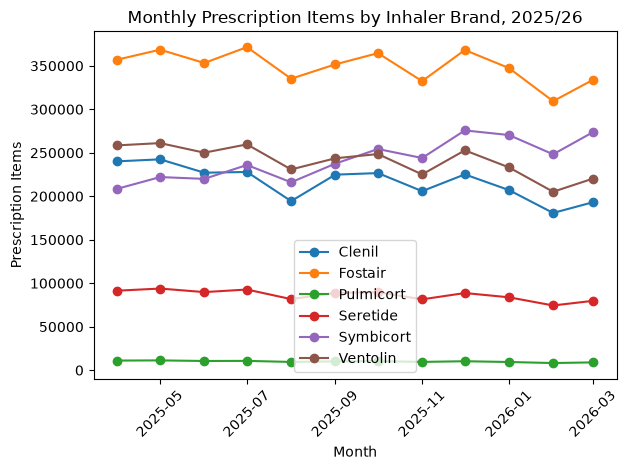

In [125]:
for inhaler in monthly_summary["Inhaler"].unique():
    inhaler_data = monthly_summary[
        monthly_summary["Inhaler"] == inhaler
    ]

    plt.plot(
        inhaler_data["Date"],
        inhaler_data["Prescription Items"],
        marker="o",
        label=inhaler
    )

plt.xlabel("Month")
plt.ylabel("Prescription Items")
plt.title("Monthly Prescription Items by Inhaler Brand, 2025/26")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/monthly_prescription_items_by_inhaler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

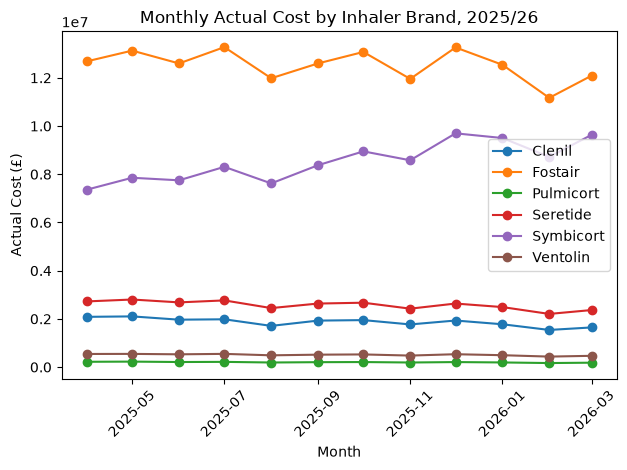

In [126]:
for inhaler in monthly_summary["Inhaler"].unique():
    inhaler_data = monthly_summary[
        monthly_summary["Inhaler"] == inhaler
    ]

    plt.plot(
        inhaler_data["Date"],
        inhaler_data["Actual Cost (£)"],
        marker="o",
        label=inhaler
    )

plt.xlabel("Month")
plt.ylabel("Actual Cost (£)")
plt.title("Monthly Actual Cost by Inhaler Brand, 2025/26")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/monthly_actual_cost_by_inhaler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key findings — monthly prescribing volume and cost

Monthly prescribing volumes showed moderate fluctuations throughout April 2025 to March 2026, rather than a consistent upward or downward trend across all six brands. Fostair remained the most frequently prescribed brand throughout the period, generally fluctuating between approximately 310,000 and 370,000 prescription items per month.

One of the clearest changes was seen with Symbicort, where monthly prescribing was generally higher toward the latter part of the study period. It increased from approximately 210,000 items in April 2025 to around 275,000 in March 2026, although this increase was not continuous and included month-to-month fluctuations. In contrast, Clenil, Ventolin and Seretide generally ended the period at lower monthly prescribing volumes than at the beginning. Pulmicort remained substantially lower-volume throughout.

Monthly expenditure broadly reflected the prescribing patterns but also demonstrated the substantial differences in cost per prescription item identified previously. Fostair consistently accounted for the highest monthly actual cost, at approximately £12–13 million per month, while Symbicort showed a notable increase in monthly expenditure over the study period, broadly corresponding with its increased prescribing volume.

For most brands, peaks and dips in monthly expenditure broadly coincided with changes in prescription-item volume. This suggests that changes in prescribing volume were an important driver of month-to-month expenditure, although differences in cost per item meant that similar prescribing volumes did not result in similar expenditure between brands.

I would not claim seasonality from these graphs. There are some recurring dips, but with only one 12-month period we don't have enough data to say there's any seasonal patterns.

## Overall Conclusion

This analysis identified substantial differences in prescribing volume, expenditure and geographic distribution between six selected asthma inhaler brands in NHS primary care during 2025/26. Fostair had both the highest prescribing volume and total actual cost, while Symbicort also accounted for substantial prescribing and expenditure. Differences in total expenditure were influenced by both prescribing volume and cost per prescription item, with Fostair, Symbicort and Seretide having markedly higher average costs per item than Ventolin and Clenil.

Prescribing also varied  between NHS areas. Pulmicort showed the greatest relative geographic variation, although absolute comparisons between areas may partly reflect differences in population size. Over the study period most brands showed month on month fluctuations rather than a consistent trend, while Symbicort displayed a general increase in both prescribing volume and expenditure toward the end of the financial year.

Overall, the findings demonstrate how prescribing volume, unit cost and geographic variation can interact to produce substantial differences in NHS expenditure between inhaler brands.

## Limitations

Several limitations should be considered when interpreting this analysis.

First
Prescription items measure prescribing activity rather than the physical quantity of medication supplied. A single prescription item may represent different quantities of inhalers. Prescription item counts therefore should not be interpreted as either the number of individual inhalers supplied or the number of patients treated.

Second, geographic comparisons were based on absolute prescription item totals and were not adjusted for population size or practice  size. Differences between NHS areas may therefore partly reflect differences in the populations they serve rather than differences in prescribing intensity alone.

Third, the six selected inhaler brands represent different medicines and therapeutic classes, including SABA, ICS and ICS/LABA treatments. Differences in prescribing volume and cost should therefore not be interpreted as  one inhaler representing better value than another.

Fourth, the analysis covers a single financial year, from April 2025 to March 2026. Although monthly fluctuations can be identified, one year of data is insufficient to establish more long term trends or seasonal prescribing patterns.

Lastly, the analysis focused on six (most common) selected inhaler brands rather than all medicines used in asthma management. The findings therefore describe prescribing patterns within this selected group and should not be interpreted as representing all asthma medicines in NHS primary care.